# **Bitcoin Market Sentiment Analysis**

## Objective:
 Analyze how Bitcoin market sentiment influences trader profitability and identify actionable insights for improving trading strategies.

# Import required Libraries:

In [3]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Statistical Analysis
from scipy import stats

# Machine Learning (Used Later)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Date & Time
from datetime import datetime

# Notebook Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


# Load both datasets into Pandas DataFrames:

In [4]:
fear_df = pd.read_csv("data/fear_greed_index.csv")
trade_df = pd.read_csv("data/historical_data.csv")

print("✅ Datasets loaded successfully.")

✅ Datasets loaded successfully.


In [5]:
# Display first 5 rows

print("Fear & Greed Dataset")
display(fear_df.head())

print("\nHistorical Trading Dataset")
display(trade_df.head())

Fear & Greed Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Historical Trading Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,1730000000000.00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,1730000000000.00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,02-12-2024 22:50,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,1730000000000.00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,02-12-2024 22:50,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,1730000000000.00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,1730000000000.00


In [6]:
# Dataset Dimensions

print("=" * 50)
print("Fear & Greed Dataset Shape")
print(fear_df.shape)

print("\nHistorical Trading Dataset Shape")
print(trade_df.shape)
print("=" * 50)

Fear & Greed Dataset Shape
(2644, 4)

Historical Trading Dataset Shape
(211224, 16)


## Dataset Overview:
Before performing any analysis, it is important to understand the structure of both datasets

In [7]:
#Fear & Greed Dataset Information

print("Fear & Greed Dataset Information")                    
fear_df.info()

Fear & Greed Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [8]:
#Historical Trading Dataset Information

print("Historical Trading Dataset Information")
trade_df.info()

Historical Trading Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-

In [9]:
#Column Names

print("Fear Dataset Columns")
print(fear_df.columns.tolist())

print("\nTrading Dataset Columns")
print(trade_df.columns.tolist())

Fear Dataset Columns
['timestamp', 'value', 'classification', 'date']

Trading Dataset Columns
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [12]:
#Statistical Summary

print("Fear Dataset Summary")
display(fear_df.describe(include="all"))

print("\nTrading Dataset Summary")
display(trade_df.describe(include="all"))

Fear Dataset Summary


,timestamp,value,classification,date
count,2644.00,2644.00,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2018-02-01
freq,NaN,NaN,781,1
mean,1631898885.02,46.98,NaN,NaN
std,65979674.32,21.83,NaN,NaN
min,1517463000.00,5.00,NaN,NaN
25%,1574811000.00,28.00,NaN,NaN
50%,1631899800.00,46.00,NaN,NaN
75%,1688988600.00,66.00,NaN,NaN



Trading Dataset Summary


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.00,211224.00,211224.00,211224,211224,211224.00,211224,211224.00,211224,211224.00,211224,211224.00,211224.00,211224.00
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.72,4623.36,5639.45,NaN,NaN,-29946.25,NaN,48.75,NaN,69653876008.97,NaN,1.16,562854854500788.50,1737744290421.54
std,NaN,NaN,29447.65,104272.89,36575.14,NaN,NaN,673807.42,NaN,919.16,NaN,18357525271.93,NaN,6.76,325756470346550.31,8689920301.57
min,NaN,NaN,0.00,0.00,0.00,NaN,NaN,-14334629.00,NaN,-117990.10,NaN,173271100.00,NaN,-1.18,0.00,1680000000000.00
25%,NaN,NaN,4.85,2.94,193.79,NaN,NaN,-376.23,NaN,0.00,NaN,59838527992.75,NaN,0.02,281000000000000.00,1740000000000.00
50%,NaN,NaN,18.28,32.00,597.05,NaN,NaN,84.73,NaN,0.00,NaN,74429390066.00,NaN,0.09,562000000000000.00,1740000000000.00
75%,NaN,NaN,101.58,187.90,2058.96,NaN,NaN,9337.28,NaN,5.79,NaN,83355430544.00,NaN,0.39,846000000000000.00,1740000000000.00


In [11]:
#Missing Values

print("Fear Dataset Missing Values")
display(fear_df.isnull().sum())

print("\nTrading Dataset Missing Values")
display(trade_df.isnull().sum())

Fear Dataset Missing Values


timestamp         0
value             0
classification    0
date              0
dtype: int64


Trading Dataset Missing Values


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [13]:
#Duplicate Records

print("Fear Dataset Duplicates :", fear_df.duplicated().sum())

print("Trading Dataset Duplicates :", trade_df.duplicated().sum())

Fear Dataset Duplicates : 0
Trading Dataset Duplicates : 0


In [14]:
#Memory Usage

print("Fear Dataset Memory Usage")

fear_memory = fear_df.memory_usage(deep=True).sum() / 1024**2

print(f"{fear_memory:.2f} MB")


print("\nTrading Dataset Memory Usage")

trade_memory = trade_df.memory_usage(deep=True).sum() / 1024**2

print(f"{trade_memory:.2f} MB")

Fear Dataset Memory Usage
0.37 MB

Trading Dataset Memory Usage
111.86 MB


### Initial Observations:

- Dataset dimensions have been verified.
- Data types have been inspected.
- Missing values and duplicate records have been identified.
- Statistical summaries provide an overview of numerical features.

These observations will guide the data cleaning and preprocessing steps 

# Data Cleaning

- Verify data types
- Convert date/time columns
- Check for blank values
- Check category consistency
- Validate numerical columns
- Detect outliers
- Prepare datasets for feature engineering

In [16]:
# Convert Date Columns
fear_df["date"] = pd.to_datetime(fear_df["date"])

trade_df["Timestamp IST"] = pd.to_datetime(
    trade_df["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

print("✅  Date columns converted successfully.")

✅  Date columns converted successfully.


In [22]:
#Verify datatypes

fear_df.dtypes

timestamp                  int64
value                      int64
classification            object
date              datetime64[ns]
dtype: object

In [23]:
trade_df.dtypes

Account                     object
Coin                        object
Execution Price            float64
Size Tokens                float64
Size USD                   float64
Side                        object
Timestamp IST       datetime64[ns]
Start Position             float64
Direction                   object
Closed PnL                 float64
Transaction Hash            object
Order ID                     int64
Crossed                       bool
Fee                        float64
Trade ID                   float64
Timestamp                  float64
dtype: object

In [24]:
#Check Blank Strings in Object column ("" instead of NaN.)

print("="*60)
print("Blank String Check")
print("="*60)

for col in fear_df.select_dtypes(include="object").columns:
    print(f"{col}: {(fear_df[col].str.strip() == '').sum()}")

print()

for col in trade_df.select_dtypes(include="object").columns:
    print(f"{col}: {(trade_df[col].str.strip() == '').sum()}")

Blank String Check
classification: 0

Account: 0
Coin: 0
Side: 0
Direction: 0
Transaction Hash: 0


In [26]:
## Remove Leading and Trailing Spaces

for col in fear_df.select_dtypes(include="object").columns:
    fear_df[col] = fear_df[col].str.strip()

for col in trade_df.select_dtypes(include="object").columns:
    trade_df[col] = trade_df[col].str.strip()

print("✅ Whitespace removed.")

✅ Whitespace removed.


In [28]:
#Category Consistency    BUY.... Buy....buy

print("Fear Classification")
print(fear_df["classification"].unique())

print("\nTrade Side")
print(trade_df["Side"].unique())

print("\nTrade Direction")
print(trade_df["Direction"].unique())

Fear Classification
['Fear' 'Extreme Fear' 'Neutral' 'Greed' 'Extreme Greed']

Trade Side
['BUY' 'SELL']

Trade Direction
['Buy' 'Sell' 'Open Long' 'Close Long' 'Spot Dust Conversion' 'Open Short'
 'Close Short' 'Long > Short' 'Short > Long' 'Auto-Deleveraging'
 'Liquidated Isolated Short' 'Settlement']


In [29]:
#Validate Numeric Columns

numeric_cols = [
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Start Position",
    "Closed PnL",
    "Fee"
]

trade_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Execution Price,211224.00,11414.72,29447.65,0.00,4.85,18.28,101.58,109004.00
Size Tokens,211224.00,4623.36,104272.89,0.00,2.94,32.00,187.90,15822438.00
Size USD,211224.00,5639.45,36575.14,0.00,193.79,597.05,2058.96,3921430.72
Start Position,211224.00,-29946.25,673807.42,-14334629.00,-376.23,84.73,9337.28,30509482.00
Closed PnL,211224.00,48.75,919.16,-117990.10,0.00,0.00,5.79,135329.09
Fee,211224.00,1.16,6.76,-1.18,0.02,0.09,0.39,837.47


In [30]:
#Check Impossible Values.....Execution Price should never be ≤ 0.

print("Execution Price <= 0 :",
      (trade_df["Execution Price"] <= 0).sum())

print("Size Tokens <= 0 :",
      (trade_df["Size Tokens"] <= 0).sum())

print("Size USD <= 0 :",
      (trade_df["Size USD"] <= 0).sum())

print("Fee < 0 :",
      (trade_df["Fee"] < 0).sum())

Execution Price <= 0 : 0
Size Tokens <= 0 : 0
Size USD <= 0 : 43
Fee < 0 : 2476


In [31]:
#Check Timestamp

trade_df["Timestamp IST"].head()

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[ns]

In [34]:
trade_df["Transaction Hash"].duplicated().sum()             #Check Duplicate Transaction Hash

110040

In [35]:
trade_df["Order ID"].duplicated().sum()               #Check Duplicate Order ID

160669

In [36]:
trade_df["Trade ID"].duplicated().sum()                  #Check Duplicate Trade ID

208414

The datasets are now ready for feature engineering.

# Feature Engineering

Feature engineering involves creating new variables from existing data to make analysis more meaningful.

In [38]:
#merge the datasets using Date, so first extract only the date from the timestamp.

trade_df["Trade Date"] = trade_df["Timestamp IST"].dt.date

fear_df["Trade Date"] = fear_df["date"].dt.date

print("✅ Trade Date created successfully.")

✅ Trade Date created successfully.


In [39]:
#Extract Time Features

trade_df["Trade Hour"] = trade_df["Timestamp IST"].dt.hour

trade_df["Day Name"] = trade_df["Timestamp IST"].dt.day_name()

trade_df["Month"] = trade_df["Timestamp IST"].dt.month_name()

trade_df["Day"] = trade_df["Timestamp IST"].dt.day

In [40]:
#Weekend Trading

trade_df["Weekend"] = trade_df["Day Name"].isin(
    ["Saturday", "Sunday"]
)

trade_df["Weekend"] = trade_df["Weekend"].map(
    {
        True: "Weekend",
        False: "Weekday"
    }
)

In [41]:
#Profit Flag........so later we can easily compute Win Rate.

trade_df["Profit Flag"] = np.where(
    trade_df["Closed PnL"] > 0,
    "Profit",
    "Loss"
)

In [43]:
#Absolute Profit/Loss               ..Useful for Largest winners and Largest losers

trade_df["Absolute PnL"] = trade_df["Closed PnL"].abs()

In [44]:
#Trade Size Category   .....divide into Small Medium Large

trade_df["Trade Size Category"] = pd.qcut(
    trade_df["Size USD"],
    q=3,
    labels=[
        "Small",
        "Medium",
        "Large"
    ]
)

In [45]:
#Fee Percentage insted of only fee

trade_df["Fee Percentage"] = (
    trade_df["Fee"] /
    trade_df["Size USD"]
) * 100

In [46]:
#Winning Trade

trade_df["Winning Trade"] = (
    trade_df["Closed PnL"] > 0
).astype(int)

In [47]:
#Losing Trade

trade_df["Losing Trade"] = (
    trade_df["Closed PnL"] < 0
).astype(int)

In [48]:
#Display Engineered Features

trade_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Trade Date,Trade Hour,Day Name,Month,Day,Weekend,Profit Flag,Absolute PnL,Trade Size Category,Fee Percentage,Winning Trade,Losing Trade
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,2024-12-02 22:50:00,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,1730000000000.00,2024-12-02,22,Monday,December,2,Weekday,Loss,0.00,Large,0.00,0,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,2024-12-02 22:50:00,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,1730000000000.00,2024-12-02,22,Monday,December,2,Weekday,Loss,0.00,Small,0.00,0,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,1730000000000.00,2024-12-02,22,Monday,December,2,Weekday,Loss,0.00,Medium,0.00,0,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,1730000000000.00,2024-12-02,22,Monday,December,2,Weekday,Loss,0.00,Medium,0.00,0,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,2024-12-02 22:50:00,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,1730000000000.00,2024-12-02,22,Monday,December,2,Weekday,Loss,0.00,Small,0.00,0,0


following features were created:

- Trade Date
- Trade Hour
- Day Name
- Month
- Weekend
- Profit Flag
- Absolute PnL
- Trade Size Category
- Fee Percentage
- Winning Trade
- Losing Trade

 these will simplify the analysis and help uncover meaningful trading patterns.

# Merge the Datasets

To analyze trader performance under different market conditions, both datasets are merged using the trading date.

After merging, every trade will be associated with the corresponding Bitcoin market sentiment on that day.

In [52]:
# Check Date Range of Both Datasets

print("Fear & Greed Dataset Date Range")
print("--------------------------------")
print("Start Date :", fear_df["Trade Date"].min())
print("End Date   :", fear_df["Trade Date"].max())

print("\nTrading Dataset Date Range")
print("--------------------------")
print("Start Date :", trade_df["Trade Date"].min())
print("End Date   :", trade_df["Trade Date"].max())

Fear & Greed Dataset Date Range
--------------------------------
Start Date : 2018-02-01
End Date   : 2025-05-02

Trading Dataset Date Range
--------------------------
Start Date : 2023-05-01
End Date   : 2025-05-01


In [54]:
# Merge Trader Data with Fear & Greed Data  ....without duplicating the date columns

merged_df = trade_df.merge(
    fear_df[
        [
            "Trade Date",
            "classification",
            "value"
        ]
    ],
    on="Trade Date",
    how="left"
)

In [55]:
# Rename Columns

merged_df.rename(
    columns={
        "classification": "Market Sentiment",
        "value": "Fear Greed Index"
    },
    inplace=True
)

In [56]:
merged_df.head()                       #verfy merge

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Trade Date,Trade Hour,Day Name,Month,Day,Weekend,Profit Flag,Absolute PnL,Trade Size Category,Fee Percentage,Winning Trade,Losing Trade,Market Sentiment,Fear Greed Index
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,2024-12-02 22:50:00,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,1730000000000.00,2024-12-02,22,Monday,December,2,Weekday,Loss,0.00,Large,0.00,0,0,Extreme Greed,80.00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,2024-12-02 22:50:00,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,1730000000000.00,2024-12-02,22,Monday,December,2,Weekday,Loss,0.00,Small,0.00,0,0,Extreme Greed,80.00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,1730000000000.00,2024-12-02,22,Monday,December,2,Weekday,Loss,0.00,Medium,0.00,0,0,Extreme Greed,80.00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,1730000000000.00,2024-12-02,22,Monday,December,2,Weekday,Loss,0.00,Medium,0.00,0,0,Extreme Greed,80.00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,2024-12-02 22:50:00,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,1730000000000.00,2024-12-02,22,Monday,December,2,Weekday,Loss,0.00,Small,0.00,0,0,Extreme Greed,80.00


In [57]:
# Check Missing Sentiment After Merge

merged_df[
    [
        "Market Sentiment",
        "Fear Greed Index"
    ]
].isnull().sum()

Market Sentiment    6
Fear Greed Index    6
dtype: int64

In [58]:
print("Merged Dataset Shape")          #dataset shape
print("--------------------")
print(merged_df.shape)

Merged Dataset Shape
--------------------
(211224, 30)


In [59]:
merged_df["Market Sentiment"].value_counts()                   #Check Sentiment Distribution

Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: Market Sentiment, dtype: int64

In [60]:
merged_df.sample(10, random_state=42)        #Verify Random Records confirm that different dates have the correct sentiment values.

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Trade Date,Trade Hour,Day Name,Month,Day,Weekend,Profit Flag,Absolute PnL,Trade Size Category,Fee Percentage,Winning Trade,Losing Trade,Market Sentiment,Fear Greed Index
204807,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,MELANIA,0.76,515.90,394.25,BUY,2025-03-08 20:36:00,-514.90,Short > Long,34.43,0xe1d7303e2fc42a7cdae5041f2778750202ae00cdaad0...,78217687750,False,0.02,455000000000000.00,1740000000000.00,2025-03-08,20,Saturday,March,8,Weekend,Profit,34.43,Medium,0.00,1,0,Fear,28.00
147143,0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0,PURR/USDC,0.16,99.00,16.02,SELL,2024-10-28 08:11:00,407428.35,Sell,2.66,0x00000000000000000000000000000000000000000000...,43593087207,False,0.00,329000000000000.00,1730000000000.00,2024-10-28,8,Monday,October,28,Weekday,Profit,2.66,Small,0.01,1,0,Greed,72.00
71059,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,17.54,115.36,2022.84,SELL,2025-03-05 04:42:00,178757.55,Close Long,106.14,0xf56d37a1433b9a919b96041eeb2cd901d200aa10e48b...,77214297554,True,0.61,1010000000000000.00,1740000000000.00,2025-03-05,4,Wednesday,March,5,Weekday,Profit,106.14,Large,0.03,1,0,Extreme Fear,20.00
198922,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,SUI,1.98,1008.10,1999.16,BUY,2025-04-06 23:49:00,62314.60,Open Long,0.00,0xc0946402f74b2419b6b3042108068f02060f00972334...,84298951614,True,0.60,86500000000000.00,1740000000000.00,2025-04-06,23,Sunday,April,6,Weekend,Loss,0.00,Large,0.03,0,0,Fear,34.00
101896,0x8477e447846c758f5a675856001ea72298fd9cb5,WLD,4.39,4.00,17.57,SELL,2024-06-10 21:10:00,-1140.40,Open Short,0.00,0xf93c774d772b2e0620c0040b23f5ee0172005f77aa76...,25553362653,True,0.01,446000000000000.00,1720000000000.00,2024-06-10,21,Monday,June,10,Weekday,Loss,0.00,Small,0.03,0,0,Greed,72.00
164536,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,29.43,15.00,441.52,SELL,2024-12-23 15:37:00,16743.94,Sell,35.32,0xf7bdcfc7c365419efbae0419da384d01f300e0324ebf...,58000121239,True,0.13,1070000000000000.00,1730000000000.00,2024-12-23,15,Monday,December,23,Weekday,Profit,35.32,Medium,0.03,1,0,Greed,70.00
170019,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,23.26,85.72,1993.85,SELL,2025-02-19 12:24:00,3797.15,Sell,24.95,0x4c084231dd238512de31041e0b2a0c020144004df924...,73349913719,True,0.70,810000000000000.00,1740000000000.00,2025-02-19,12,Wednesday,February,19,Weekday,Profit,24.95,Large,0.03,1,0,Fear,44.00
149480,0xb899e522b5715391ae1d4f137653e7906c5e2115,SOL,127.47,54.92,7000.65,SELL,2025-03-09 22:38:00,5016.35,Close Long,6.69,0xc89ce8d0c276c4717761041f3944000201fb00fe8751...,78428682687,True,1.75,163000000000000.00,1740000000000.00,2025-03-09,22,Sunday,March,9,Weekend,Profit,6.69,Large,0.03,1,0,Fear,27.00
96078,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,HYPE,24.35,2.90,70.62,SELL,2025-02-20 06:12:00,1973.26,Close Long,0.51,0xfa5553e79649cb929e6a041e1750c101a80057203d32...,73524846595,False,0.00,188000000000000.00,1740000000000.00,2025-02-20,6,Thursday,February,20,Weekday,Profit,0.51,Small,0.00,1,0,Neutral,49.00
136536,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,HYPE,19.28,14.05,270.88,BUY,2025-01-10 01:35:00,100.21,Open Long,0.00,0x63570857afec144fc020041b111a4f01e4002c25c3c5...,61865059329,True,0.09,359000000000000.00,1740000000000.00,2025-01-10,1,Friday,January,10,Weekday,Loss,0.00,Small,0.04,0,0,Neutral,50.00


In [61]:
print("="*60)                                          #final verification
print("Merged Dataset Information")
print("="*60)

print(f"Rows    : {merged_df.shape[0]}")
print(f"Columns : {merged_df.shape[1]}")

print("\nUnique Market Sentiments")

print(merged_df["Market Sentiment"].unique())

Merged Dataset Information
Rows    : 211224
Columns : 30

Unique Market Sentiments
['Extreme Greed' 'Extreme Fear' 'Fear' 'Greed' 'Neutral' nan]


Each trade now contains:

- Market Sentiment
- Fear & Greed Index Value

# Exploratory Data Analysis (EDA)

here we'll explore the merged dataset to understand trader behavior, market sentiment, profitability, and hidden trading patterns.

In [62]:
#Dataset Overview let's understand the merged dataset.

print("Total Trades :", len(merged_df))
print("Unique Traders :", merged_df["Account"].nunique())
print("Unique Coins :", merged_df["Coin"].nunique())


Total Trades : 211224
Unique Traders : 32
Unique Coins : 246


In [63]:
print("Start Date :", merged_df["Trade Date"].min())                        #trading range
print("End Date :", merged_df["Trade Date"].max())

Start Date : 2023-05-01
End Date : 2025-05-01


In [65]:
merged_df["Coin"].value_counts().head(10)                          #top 10 coins

HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: Coin, dtype: int64

- The dataset contains trading activity from multiple accounts.
- Several cryptocurrencies are traded.
- The dataset spans multiple trading days.

## Market Sentiment Analysis:

### 1. Sentiment Distribution:

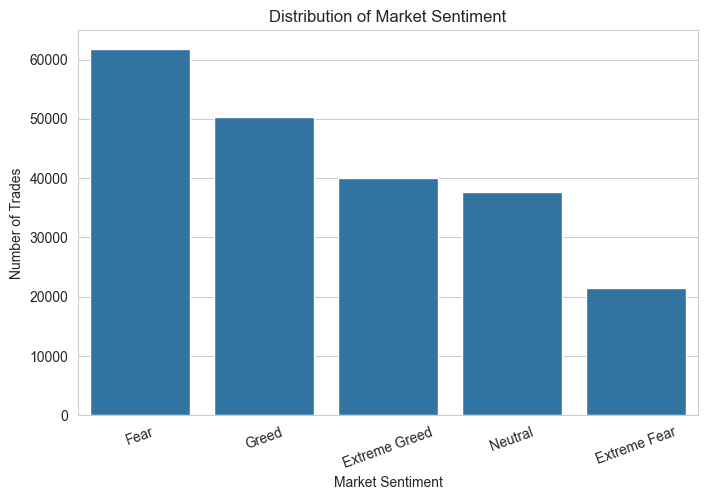

In [67]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x="Market Sentiment",
    order=merged_df["Market Sentiment"].value_counts().index
)

plt.title("Distribution of Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Number of Trades")

plt.xticks(rotation=20)

plt.show()

#### -Business Question

How are trading activities distributed across different Bitcoin market sentiment categories?

#### -Observation

The highest number of trades occurred during **Fear** (approximately 61,000 trades), followed by **Greed** (around 50,000 trades). Trading activity gradually decreased for **Extreme Greed** and **Neutral**, while **Extreme Fear** recorded the lowest number of trades (around 21,000).

#### -Business Insight

The distribution indicates that traders were most active during **Fear** rather than **Extreme Fear** or **Extreme Greed**. This suggests that moderate market uncertainty encourages greater trading participation, whereas extremely fearful market conditions may discourage trading activity due to increased risk aversion.

#### -Conclusion

Market sentiment influences trader participation. However, this visualization only reflects the **volume of trading activity** and does not indicate whether traders were profitable. Subsequent analyses will determine whether higher trading activity translates into better trading performance.

### 2. Pie Chart

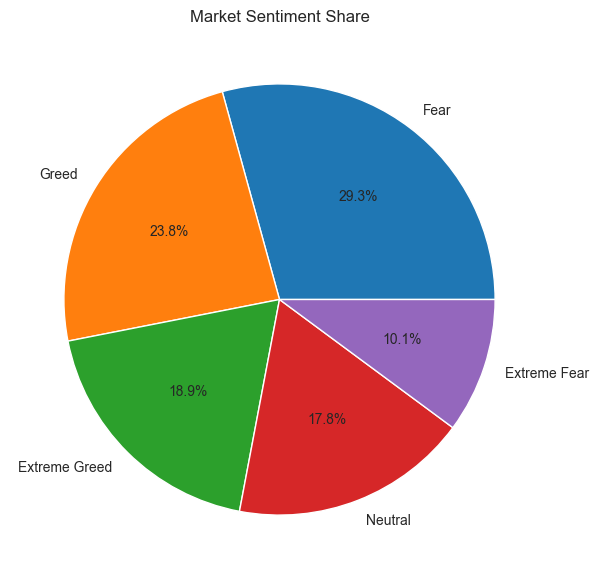

In [68]:
merged_df["Market Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.ylabel("")

plt.title("Market Sentiment Share")

plt.show()

#### -Business Question:

What proportion of total trading activity occurred under each Bitcoin market sentiment category?

#### -Observation:

The pie chart shows that **Fear** accounts for the largest share of total trades (**29.3%**), followed by **Greed** (**23.8%**). **Extreme Greed** and **Neutral** contribute **18.9%** and **17.8%**, respectively, while **Extreme Fear** represents the smallest share of trading activity (**10.1%**).

#### -Business Insight:

The distribution indicates that traders were most active during **Fear** and **Greed**, together accounting for more than half of all trades. In contrast, **Extreme Fear** witnessed significantly lower participation, suggesting that traders tend to avoid entering the market during periods of extreme uncertainty and panic.

#### -Conclusion:

The market sentiment distribution reveals that trading activity is concentrated around moderate market conditions rather than extreme emotions. However, trading frequency alone does not indicate trading success, making it essential to examine profitability under each sentiment in the following analyses.

### 3. Fear & Greed Index Distribution:

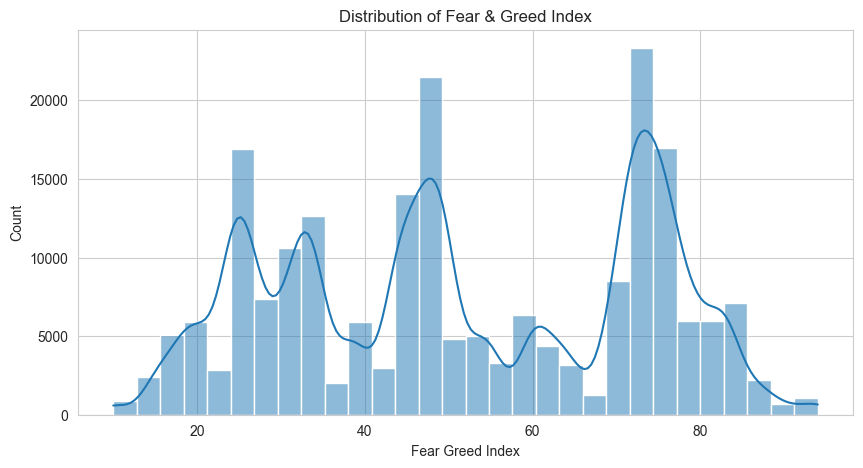

In [69]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged_df["Fear Greed Index"],
    bins=30,
    kde=True
)

plt.title("Distribution of Fear & Greed Index")

plt.show()

#### -Business Question:

How are the Fear & Greed Index values distributed throughout the trading period, and what do they reveal about overall market sentiment?

#### -Observation:

The Fear & Greed Index values are distributed across a wide range (approximately **10 to 95**), indicating that the market experienced multiple sentiment conditions during the observation period. The histogram shows several peaks, with higher concentrations around the **25–35**, **45–50**, and **70–80** index ranges, suggesting that the market frequently transitioned between Fear, Neutral, and Greed phases rather than remaining in a single sentiment.

#### -Business Insight:

The presence of multiple peaks indicates that the cryptocurrency market is highly dynamic, with sentiment changing frequently over time. This variation provides a strong foundation for analyzing whether trader behavior and profitability differ across changing market conditions.

#### -Conclusion:

The Fear & Greed Index exhibits substantial variation throughout the dataset, confirming that traders operated under diverse market sentiments. This makes the dataset suitable for investigating the relationship between market psychology and trading performance in subsequent analyses.

## Trader Behavior Analysis:


### 4. BUY vs SELL:

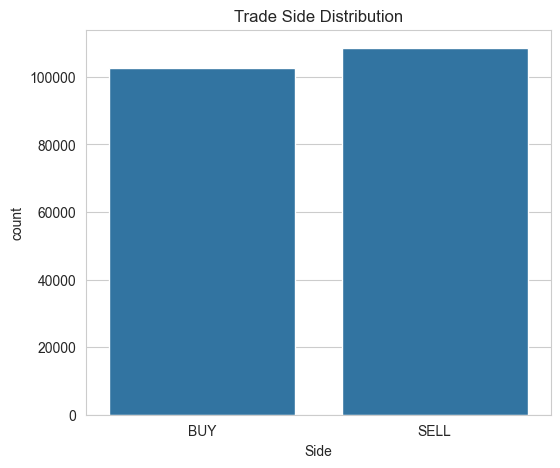

In [71]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=merged_df,
    x="Side"
)

plt.title("Trade Side Distribution")

plt.show()

#### -Business Question:

Do traders show a preference for buying or selling positions in the cryptocurrency market?

#### -Observation:

The distribution of trade sides is relatively balanced, with **SELL** trades occurring slightly more frequently than **BUY** trades. This indicates that traders actively participated on both sides of the market rather than exhibiting a strong directional bias.

#### -Business Insight:

The nearly equal distribution of BUY and SELL orders suggests a healthy and liquid trading environment where traders continuously open and close positions based on changing market conditions. The slight dominance of SELL trades may indicate increased profit-booking or hedging activity during the observed period.

#### -Conclusion:

Trader participation is well balanced between buying and selling activities, indicating that both bullish and bearish trading opportunities were actively utilized. However, trade frequency alone does not reveal which side generated better returns, making profitability analysis essential in the subsequent sections.

### 5. Trade Direction:

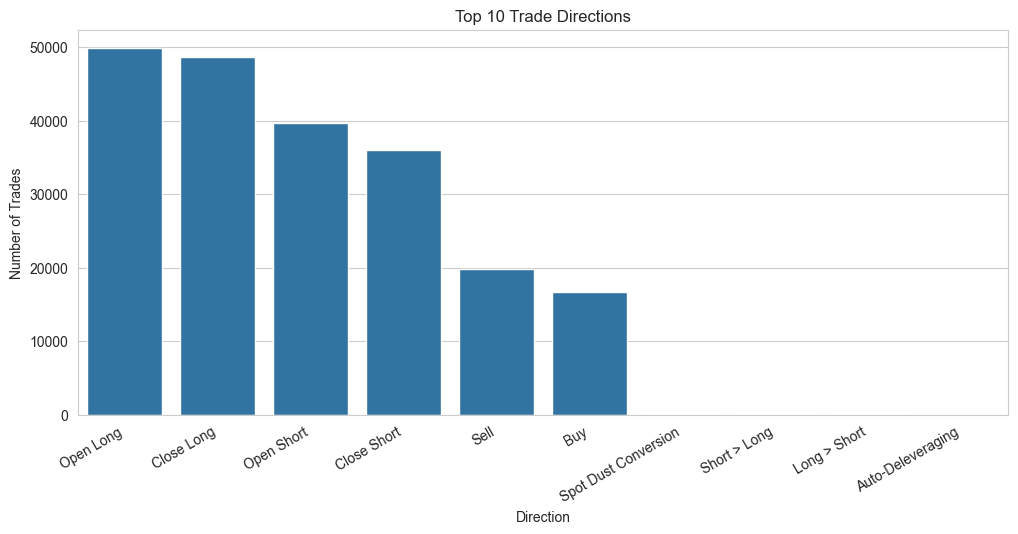

In [105]:
top_direction = merged_df["Direction"].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_direction.index,
    y=top_direction.values
)

plt.title("Top 10 Trade Directions")
plt.xlabel("Direction")
plt.ylabel("Number of Trades")
plt.xticks(rotation=30, ha="right")

plt.show()

#### -Business Question:

Which trade directions are most frequently executed by traders, and what does this reveal about their trading strategies?

#### -Observation:

The distribution shows that a few trade directions, particularly **Open Long**, **Close Long**, **Open Short**, and **Close Short**, account for the majority of trading activity. In contrast, other direction categories appear only rarely, indicating that traders predominantly rely on a limited set of trading actions.

#### -Business Insight:

The dominance of standard long and short position management suggests that most traders follow conventional directional trading strategies rather than employing complex or infrequently used order types. The balanced presence of both opening and closing positions also indicates active position management throughout the trading period.

#### -Conclusion:

Trading behavior is primarily concentrated around opening and closing long and short positions, reflecting active portfolio management. Since only a few direction categories dominate overall trading activity, subsequent analyses should focus on evaluating the profitability of these major trading strategies under different market sentiment conditions.

### 6. Trading Hour:

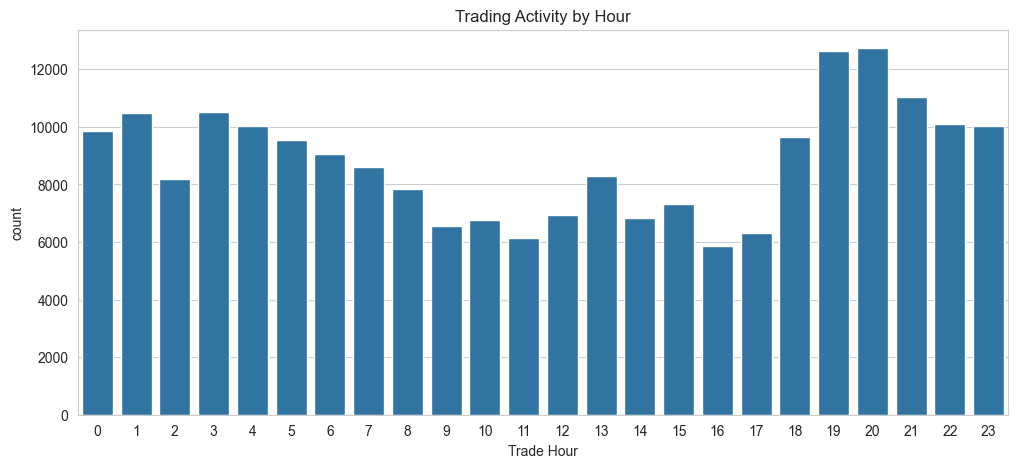

Trading activity varies throughout the day.

Peak trading hours may correspond to periods of higher market liquidity.


In [74]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=merged_df,
    x="Trade Hour"
)

plt.title("Trading Activity by Hour")

plt.show()

print('''Trading activity varies throughout the day.

Peak trading hours may correspond to periods of higher market liquidity.''')

#### -Business Question:

At what time of the day is trading activity highest, and how does trader participation vary across different hours?

#### -Observation:

Trading activity fluctuates throughout the day rather than remaining constant. The highest number of trades is observed during the **19:00–20:00** time window, with trading volume remaining relatively high between **18:00 and 23:00**. In contrast, trading activity is lowest during the **early afternoon (approximately 11:00–17:00)**, indicating reduced market participation during these hours.

#### -Business Insight:

The concentration of trading activity during the evening hours suggests that traders are more active when market participation and liquidity are higher. This could coincide with overlapping trading sessions across major global markets, encouraging increased trading activity and potentially greater market volatility.

#### -Conclusion:

Trading activity is highly time-dependent, with clear peak and off-peak periods. Identifying these high-activity hours can help traders optimize execution timing, improve liquidity, and potentially reduce slippage during order placement.

### 7. Weekend vs Weekday:

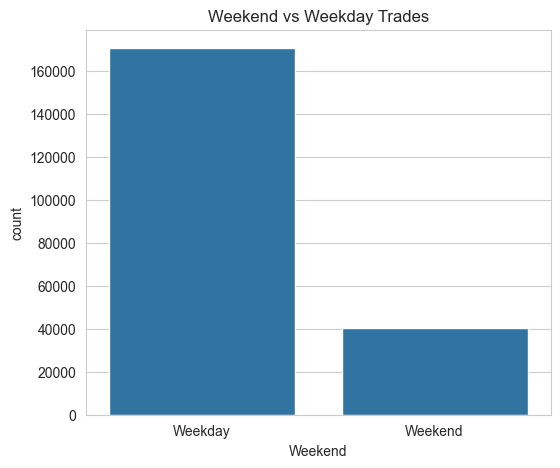

In [75]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=merged_df,
    x="Weekend"
)

plt.title("Weekend vs Weekday Trades")

plt.show()

#### -Business Question:

Does trading activity differ between weekdays and weekends?

#### -Observation:

The chart shows that the majority of trading activity occurs on **weekdays**, with approximately **170,000 trades**, whereas **weekends** account for only around **40,000 trades**. This indicates a significantly higher level of trader participation during weekdays.

#### -Business Insight:

The substantial difference in trading activity suggests that traders are more active during weekdays, likely due to higher market participation, increased institutional involvement, and greater liquidity. Lower weekend activity may reflect reduced market engagement and a preference among traders to avoid holding or initiating positions during weekends.

#### -Conclusion:

Trading activity is heavily concentrated on weekdays, indicating that market participation follows a clear weekly pattern. Traders seeking higher liquidity and increased market activity may find weekdays more favorable for executing trades.

### Profitability Analysis:

### 8. Profit vs Loss:

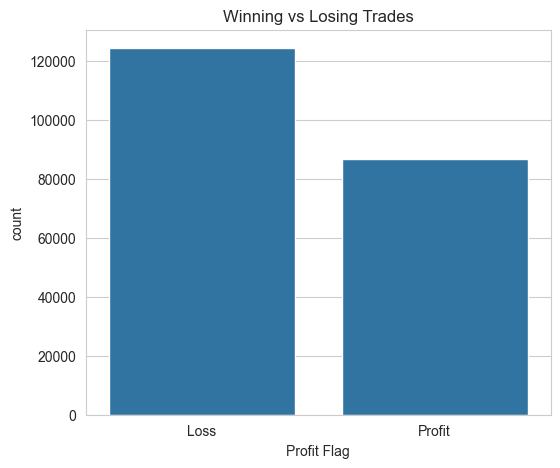

In [76]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=merged_df,
    x="Profit Flag"
)

plt.title("Winning vs Losing Trades")

plt.show()

#### -Business Question:

Are traders generally profitable, or do loss-making trades outnumber profitable trades?

#### -Observation:

The chart indicates that **loss-making trades** are more frequent than **profitable trades**. Approximately **124,000 trades** resulted in losses, while around **87,000 trades** generated profits, showing a noticeable imbalance in trading outcomes.

#### -Business Insight:

The higher number of losing trades suggests that achieving consistent profitability in cryptocurrency trading is challenging. This may be due to market volatility, ineffective risk management, or unsuccessful trading decisions. However, the number of winning trades alone does not determine overall profitability, as a smaller number of high-profit trades can still outweigh numerous small losses.

#### -Conclusion:

The dataset reveals that traders experienced losses more frequently than profits, highlighting the importance of effective trading strategies and disciplined risk management. Further analysis of **Closed PnL** is necessary to determine whether fewer profitable trades generated enough returns to offset the larger number of losing trades.

### 9. Profit / Loss.....PnL Distribution:

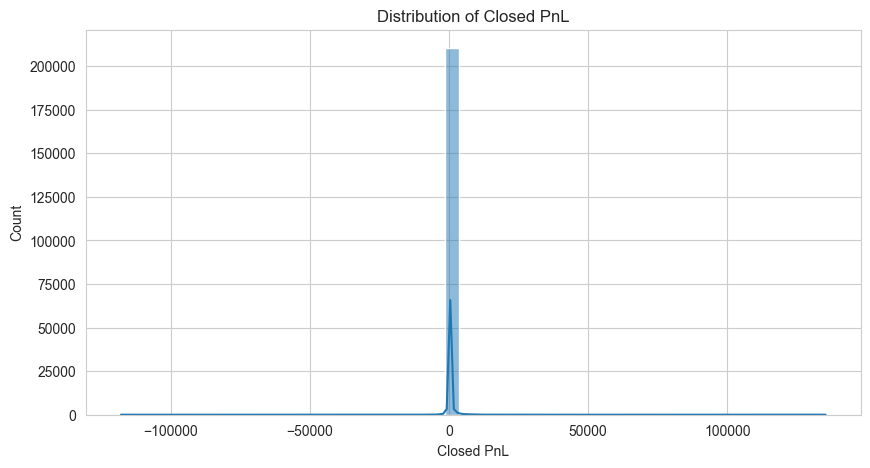

In [77]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged_df["Closed PnL"],
    bins=50,
    kde=True
)

plt.title("Distribution of Closed PnL")

plt.show()

#### -Business Question:

How are profits and losses distributed across all completed trades, and what does the distribution reveal about trader performance?

#### -Observation:

The distribution of **Closed PnL** is highly concentrated around **0**, with a sharp central peak and long tails extending in both the positive and negative directions. This indicates that most trades resulted in relatively small profits or losses, while a limited number of trades generated extremely large gains or losses (outliers).

#### -Business Insight:

The highly skewed distribution suggests that cryptocurrency trading is characterized by occasional high-impact trades that can significantly influence overall profitability. Since a few extreme trades dominate the distribution, relying solely on the average profit may lead to misleading conclusions. Therefore, additional measures such as the **median**, **boxplots**, and **sentiment-wise profitability analysis** are essential for obtaining a more accurate understanding of trading performance.

#### -Conclusion:

The Closed PnL distribution demonstrates that most trades produce modest outcomes, whereas a small number of exceptional trades account for substantial profits or losses. This highlights the importance of robust risk management and the need to analyze profitability using multiple statistical measures rather than depending only on average values.

### 10. Boxplot:

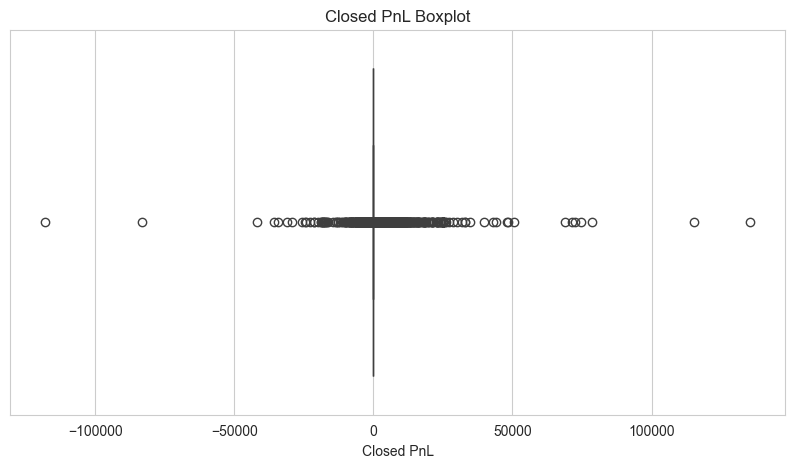

The boxplot helps identify extreme profits and losses.

Outliers are expected in cryptocurrency trading and should not be removed without investigation.


In [79]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=merged_df["Closed PnL"]
)

plt.title("Closed PnL Boxplot")

plt.show()

print('''The boxplot helps identify extreme profits and losses.

Outliers are expected in cryptocurrency trading and should not be removed without investigation.''')

#### -Business Question:

Are there any extreme profit or loss values in the trading dataset, and should they be treated as outliers?

#### -Observation:

The boxplot reveals a large number of observations clustered around the median, while several data points extend far beyond the whiskers on both the positive and negative sides. These extreme values indicate the presence of significant profit and loss outliers, with some trades recording exceptionally high gains and others experiencing substantial losses.

#### -Business Insight:

In cryptocurrency trading, extreme profits and losses are expected due to the market's high volatility and the presence of large position sizes. These observations are more likely to represent genuine trading outcomes rather than data errors. Therefore, removing them without proper investigation could eliminate valuable information and lead to misleading analytical results.

#### -Conclusion:

The dataset contains numerous legitimate extreme profit and loss values, reflecting the inherent volatility of cryptocurrency markets. These outliers will be retained throughout the analysis, while robust statistical measures such as the **median**, **interquartile range (IQR)**, and **sentiment-wise comparisons** will be used to minimize their influence on overall conclusions.

## Sentiment vs Trading Performance:

### 11. Average PnL:

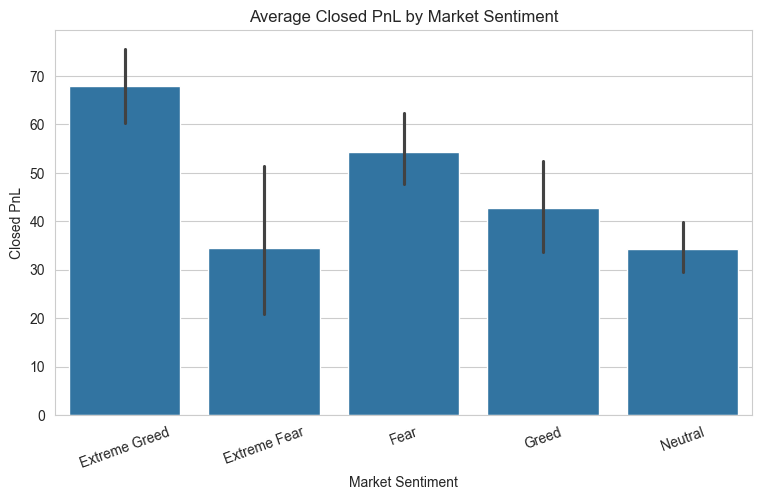

In [81]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=merged_df,
    x="Market Sentiment",
    y="Closed PnL",
    estimator=np.mean
)

plt.title("Average Closed PnL by Market Sentiment")

plt.xticks(rotation=20)

plt.show()

#### -Business Question:

How does average trader profitability vary across different Bitcoin market sentiment categories?

#### -Observation:

The chart shows that **Extreme Greed** has the highest average **Closed PnL** (approximately **68**), followed by **Fear** (around **54**). **Greed** records a moderate average profit (approximately **43**), while **Extreme Fear** and **Neutral** exhibit the lowest average profits (around **34** each). This indicates noticeable differences in trader profitability across market sentiment categories.

#### -Business Insight:

Interestingly, the highest average profitability is observed during **Extreme Greed**, suggesting that traders who successfully capitalize on strong bullish market conditions can achieve higher returns. However, **Fear** also demonstrates relatively high average profits, indicating that periods of market uncertainty may create profitable opportunities for disciplined traders. In contrast, **Neutral** and **Extreme Fear** market conditions appear to offer comparatively lower profit potential.

#### -Conclusion:

Average trader profitability varies across different market sentiments, indicating that market psychology influences trading outcomes. However, these observations should be validated using statistical tests such as **ANOVA** to determine whether the differences in average profitability are statistically significant rather than occurring due to random variation.

### 13. Trade Size:

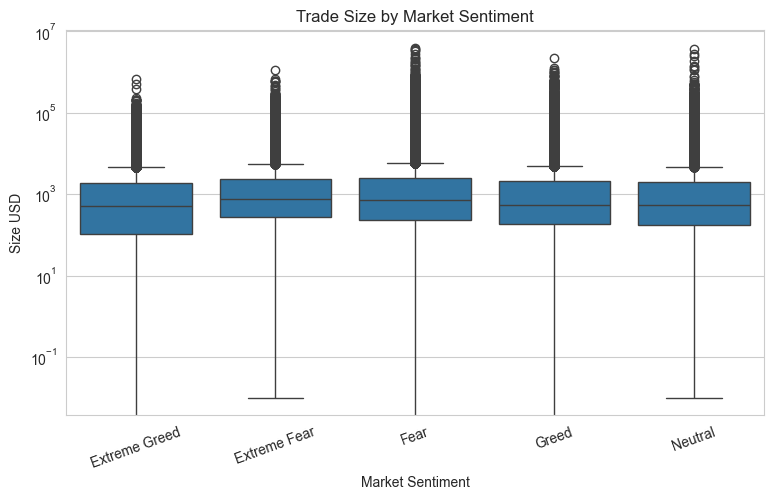

In [83]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=merged_df,
    x="Market Sentiment",
    y="Size USD"
)

plt.yscale("log")

plt.title("Trade Size by Market Sentiment")

plt.xticks(rotation=20)

plt.show()

#### -Business Question:

Does market sentiment influence the size of trades executed by traders?

#### -Observation:

The boxplot shows that the median trade size remains relatively similar across all market sentiment categories, with **Fear**, **Greed**, **Neutral**, **Extreme Fear**, and **Extreme Greed** exhibiting comparable distributions. However, every sentiment category contains numerous high-value outliers, indicating the presence of exceptionally large trades. Among them, **Fear** appears to have the widest spread and the largest extreme trade sizes.

#### -Business Insight:

The similarity in median trade sizes suggests that market sentiment alone does not substantially alter the typical position size taken by traders. Nevertheless, the presence of large outliers across all sentiment categories indicates that high-volume traders (or "whales") remain active regardless of market conditions. The greater variability observed during **Fear** may imply that experienced traders capitalize on volatile market conditions by executing larger positions.

#### -Conclusion:

Trade sizes remain broadly consistent across different market sentiments, while extreme high-value trades occur under every market condition. This suggests that although overall trading behavior remains stable, periods of heightened uncertainty—particularly **Fear**—may encourage larger trades from high-capital participants, warranting further investigation into whether these larger positions translate into higher profitability.

### 14. Winning rate:

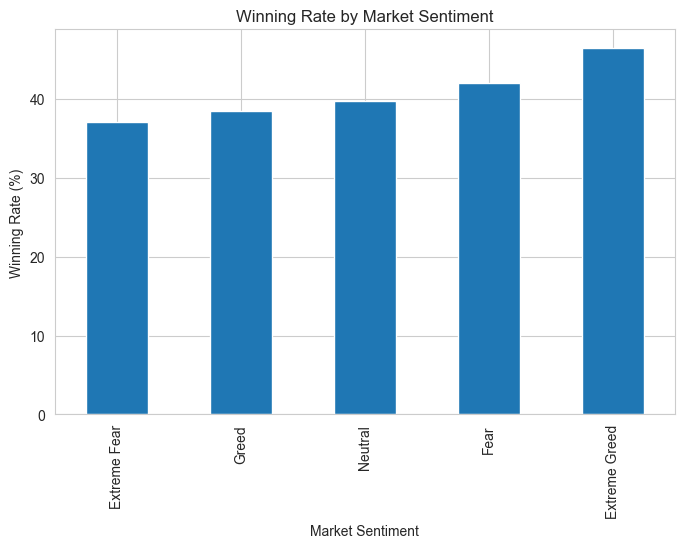

In [84]:
win_rate = merged_df.groupby(
    "Market Sentiment"
)["Winning Trade"].mean()*100

win_rate.sort_values().plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Winning Rate (%)")

plt.title("Winning Rate by Market Sentiment")

plt.show()

#### -Business Question:

How does the winning rate of traders vary across different Bitcoin market sentiment categories?

#### -Observation:

The winning rate varies noticeably across different market sentiment categories. **Extreme Greed** records the highest winning rate at approximately **46%**, followed by **Fear** (**42%**). **Neutral** and **Greed** exhibit moderate winning rates of around **40%** and **38%**, respectively, while **Extreme Fear** has the lowest winning rate at approximately **37%**.

#### -Business Insight:

The higher winning rates observed during **Extreme Greed** and **Fear** suggest that traders may achieve better trading outcomes during periods of strong market momentum or heightened volatility. Conversely, the lower winning rate during **Extreme Fear** indicates that extreme market pessimism presents more challenging trading conditions, potentially leading to less successful trades.

#### -Conclusion:

Trader success is influenced by prevailing market sentiment, with **Extreme Greed** providing the most favorable trading conditions in terms of winning percentage. However, since winning rate does not account for the magnitude of profits or losses, it should be interpreted alongside **Average Closed PnL** and other profitability metrics to obtain a comprehensive assessment of trading performance.-

### 15. Fee Distribution:

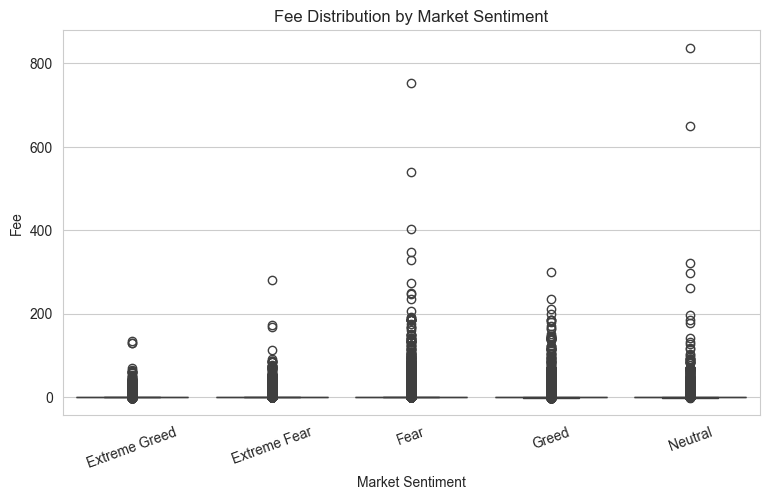

In [86]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=merged_df,
    x="Market Sentiment",
    y="Fee"
)

plt.xticks(rotation=20)

plt.title("Fee Distribution by Market Sentiment")

plt.show()

## Advanced Exploratory Data Analysis:

objective is to identify:

- Most profitable traders
- Worst-performing traders
- Best-performing cryptocurrencies
- Trading activity over time
- Relationship between trade size and profitability
- Correlation among numerical variables

### Top 20 Most Profitable Traders:
Which traders earned the highest profit?

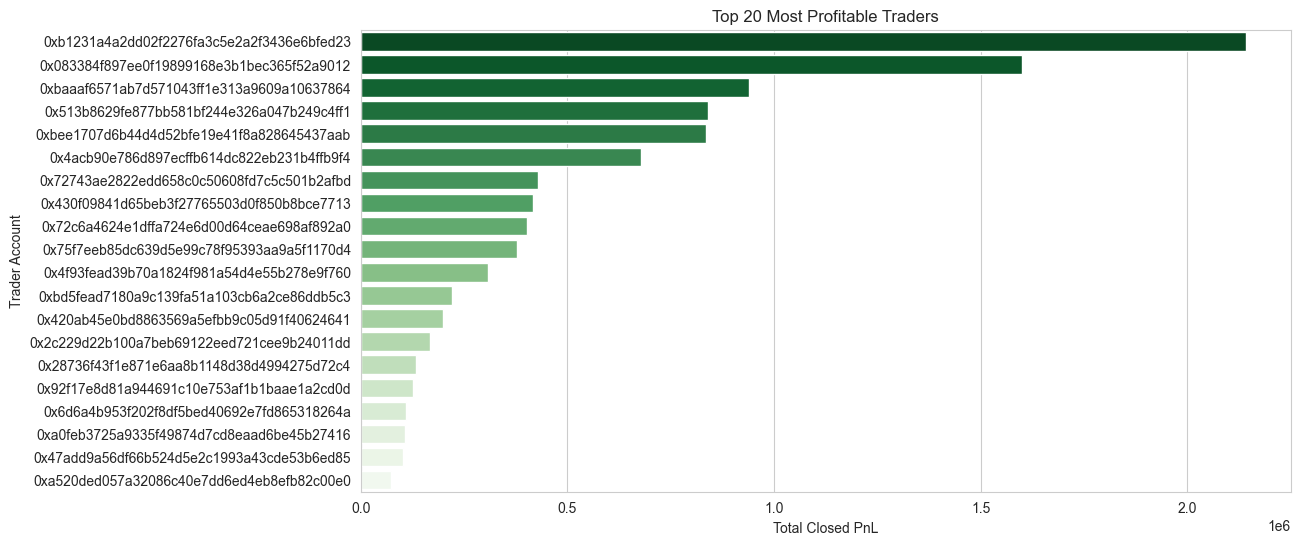

In [88]:
top_profit = (
    merged_df.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_profit.values,
    y=top_profit.index,
    palette="Greens_r"
)

plt.title("Top 20 Most Profitable Traders")
plt.xlabel("Total Closed PnL")
plt.ylabel("Trader Account")

plt.show()

- The chart identifies the traders with the highest cumulative profits.
- A small number of traders often account for a significant portion of total profits.

### Top 20 Loss-Making Traders:

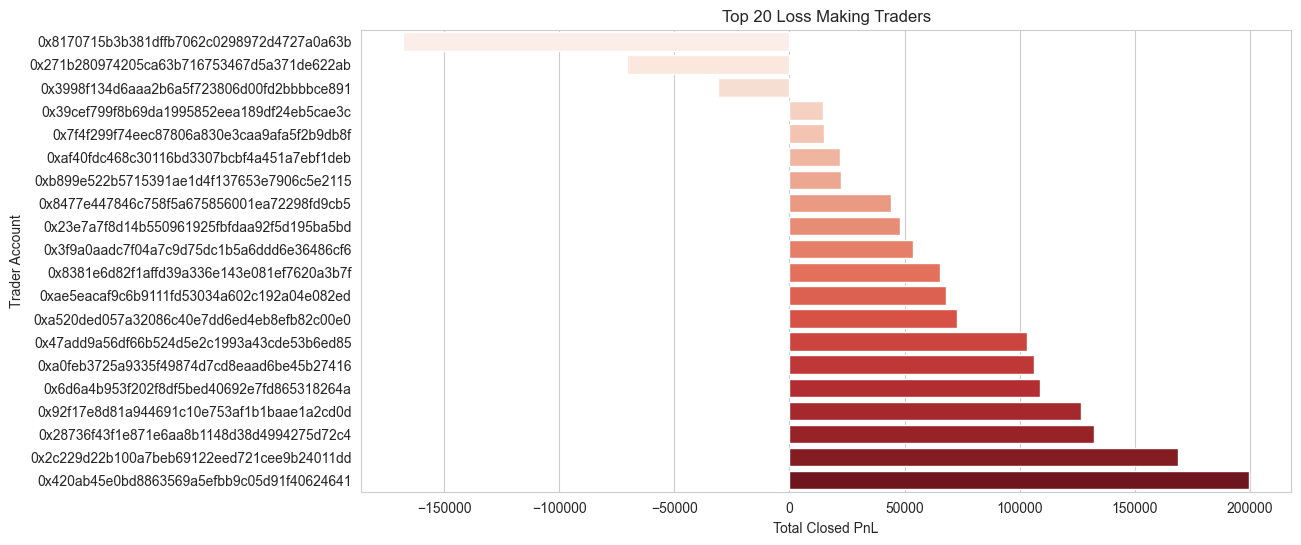

In [89]:
top_loss = (
    merged_df.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values()
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_loss.values,
    y=top_loss.index,
    palette="Reds"
)

plt.title("Top 20 Loss Making Traders")
plt.xlabel("Total Closed PnL")
plt.ylabel("Trader Account")

plt.show()

### Top Coins by Trading Volume:

Which cryptocurrencies are traded the most?

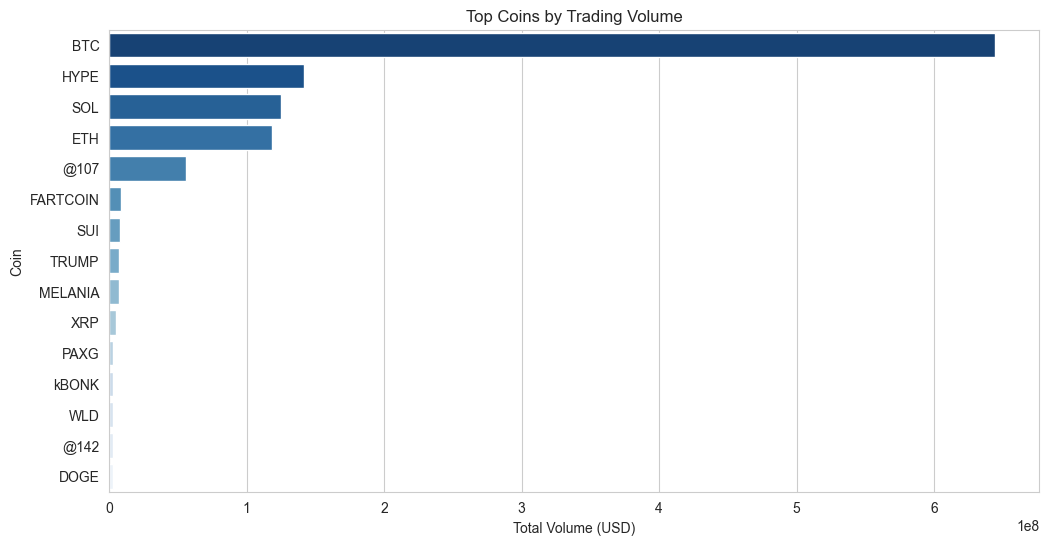

In [90]:
coin_volume = (
    merged_df.groupby("Coin")["Size USD"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=coin_volume.values,
    y=coin_volume.index,
    palette="Blues_r"
)

plt.title("Top Coins by Trading Volume")

plt.xlabel("Total Volume (USD)")
plt.ylabel("Coin")

plt.show()

### Average Profit by Coin:

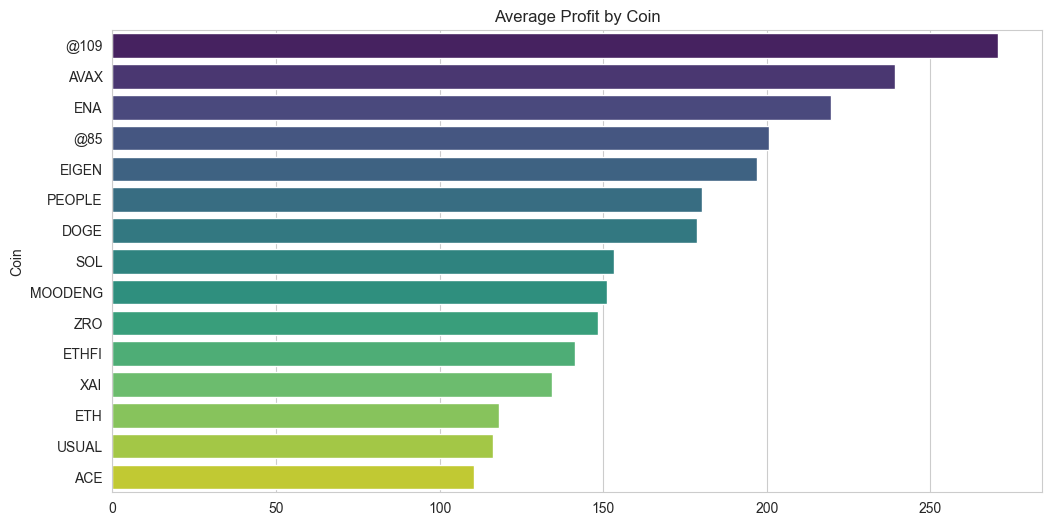

In [92]:
coin_profit = (
    merged_df.groupby("Coin")["Closed PnL"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=coin_profit.values,
    y=coin_profit.index,
    palette="viridis"
)

plt.title("Average Profit by Coin")

plt.show()

### Profit by Weekday:

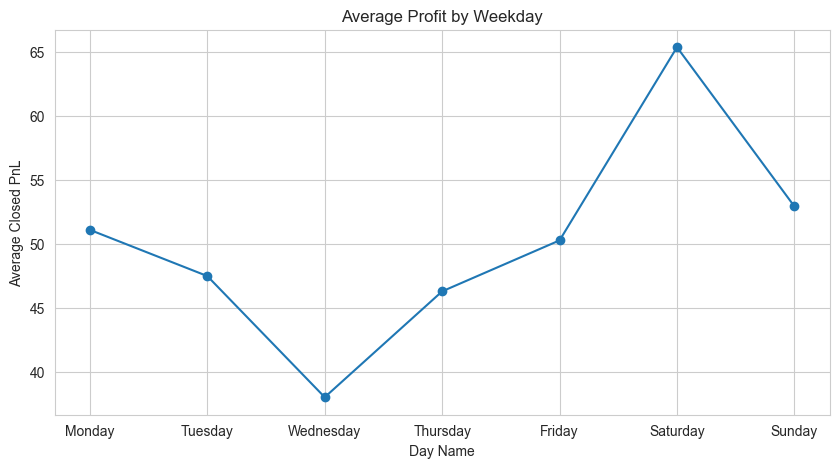

In [93]:
weekday_profit = (
    merged_df.groupby("Day Name")["Closed PnL"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

plt.figure(figsize=(10,5))

weekday_profit.plot(marker="o")

plt.title("Average Profit by Weekday")

plt.ylabel("Average Closed PnL")

plt.grid(True)

plt.show()

### Profit by Trading Hour:

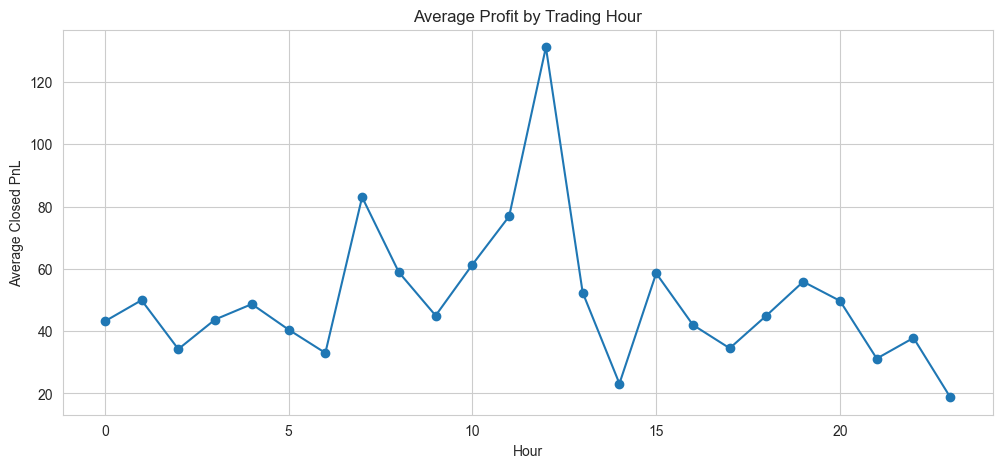

In [94]:
hour_profit = (
    merged_df.groupby("Trade Hour")["Closed PnL"]
    .mean()
)

plt.figure(figsize=(12,5))

hour_profit.plot(marker="o")

plt.title("Average Profit by Trading Hour")

plt.xlabel("Hour")

plt.ylabel("Average Closed PnL")

plt.grid(True)

plt.show()

### Daily Trading Volume:

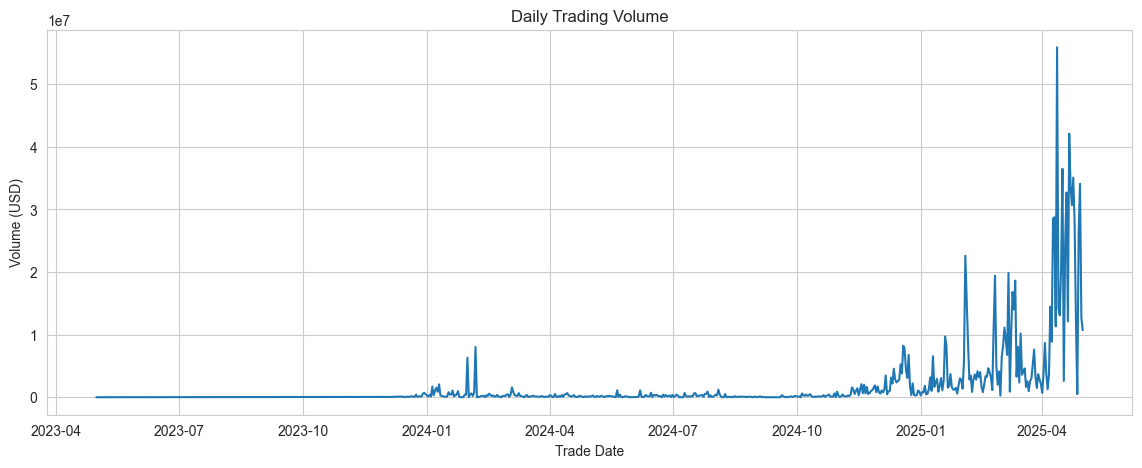

In [95]:
daily_volume = (
    merged_df.groupby("Trade Date")["Size USD"]
    .sum()
)

plt.figure(figsize=(14,5))

daily_volume.plot()

plt.title("Daily Trading Volume")

plt.ylabel("Volume (USD)")

plt.show()

### Daily Profit:

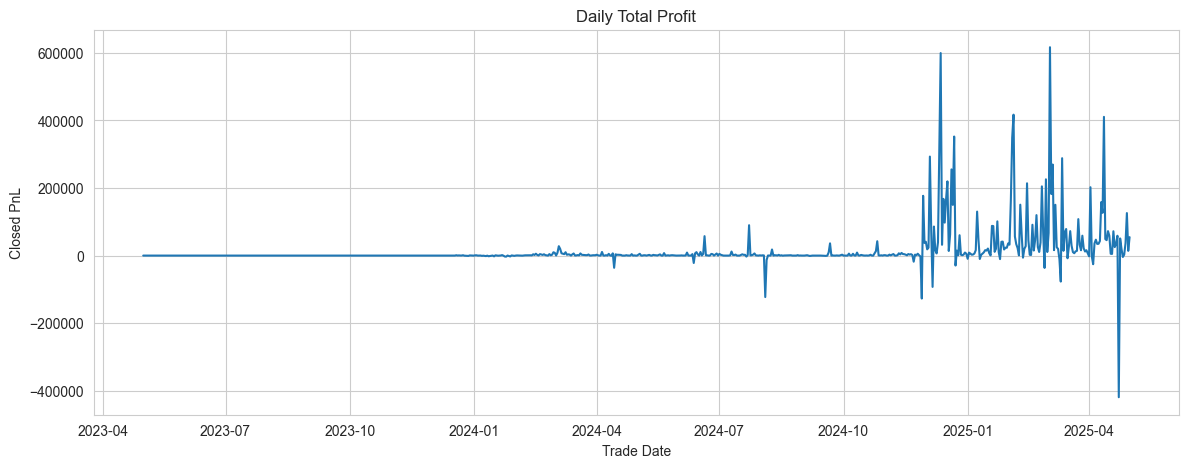

In [97]:
daily_pnl = (
    merged_df.groupby("Trade Date")["Closed PnL"]
    .sum()
)

plt.figure(figsize=(14,5))

daily_pnl.plot()

plt.title("Daily Total Profit")

plt.ylabel("Closed PnL")

plt.show()

### Trade Size vs Profit:

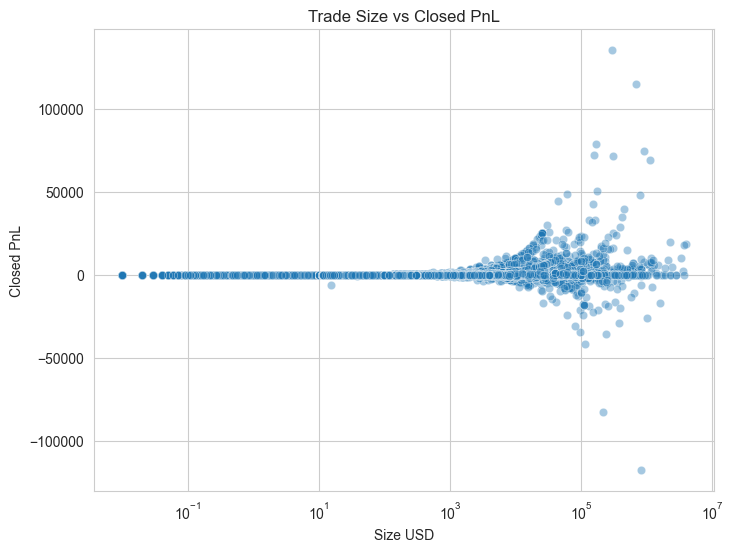

In [98]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged_df,
    x="Size USD",
    y="Closed PnL",
    alpha=0.4
)

plt.xscale("log")

plt.title("Trade Size vs Closed PnL")

plt.show()

### Correlation Heatmap:

Which numerical variables are correlated?

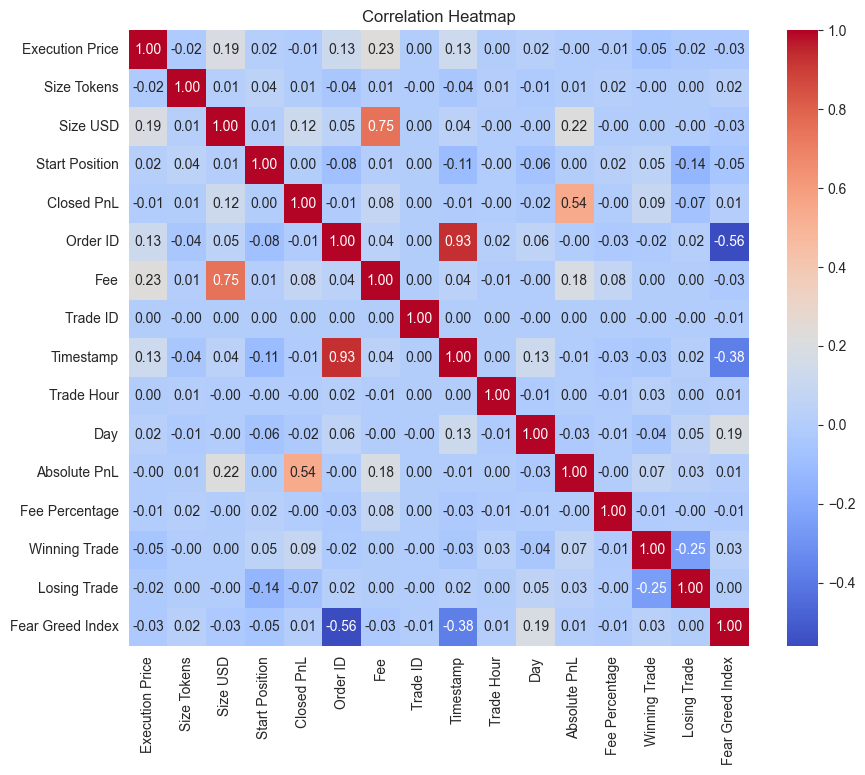

In [99]:
numeric_df = merged_df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Coin vs Market Sentiment:

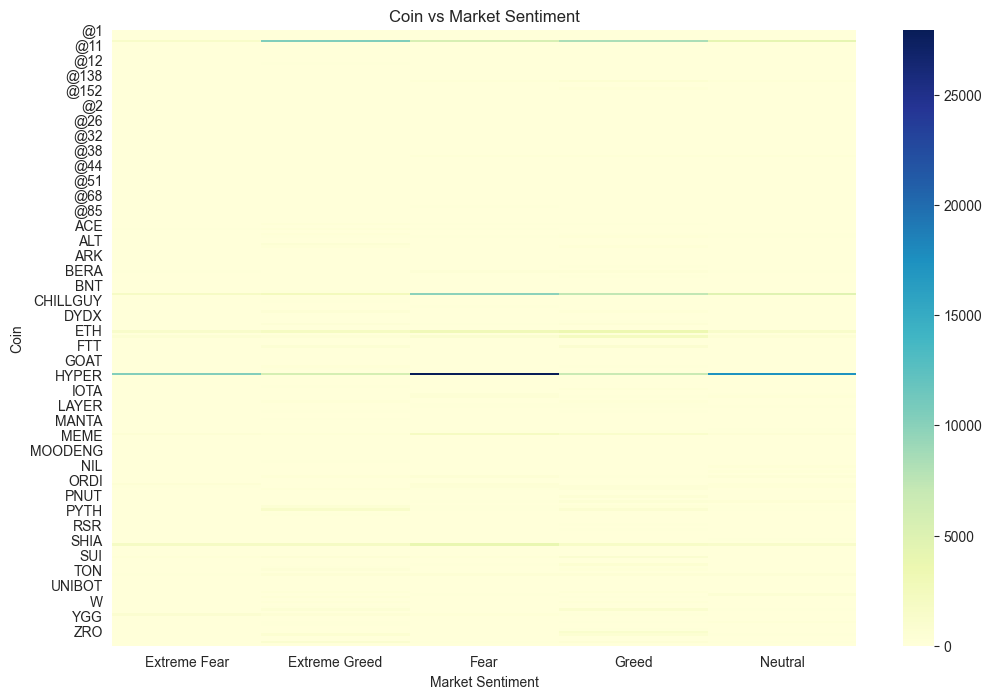

In [100]:
coin_sentiment = pd.crosstab(
    merged_df["Coin"],
    merged_df["Market Sentiment"]
)

plt.figure(figsize=(12,8))

sns.heatmap(
    coin_sentiment,
    cmap="YlGnBu"
)

plt.title("Coin vs Market Sentiment")

plt.show()

#### Average Profit under Different Sentiments:

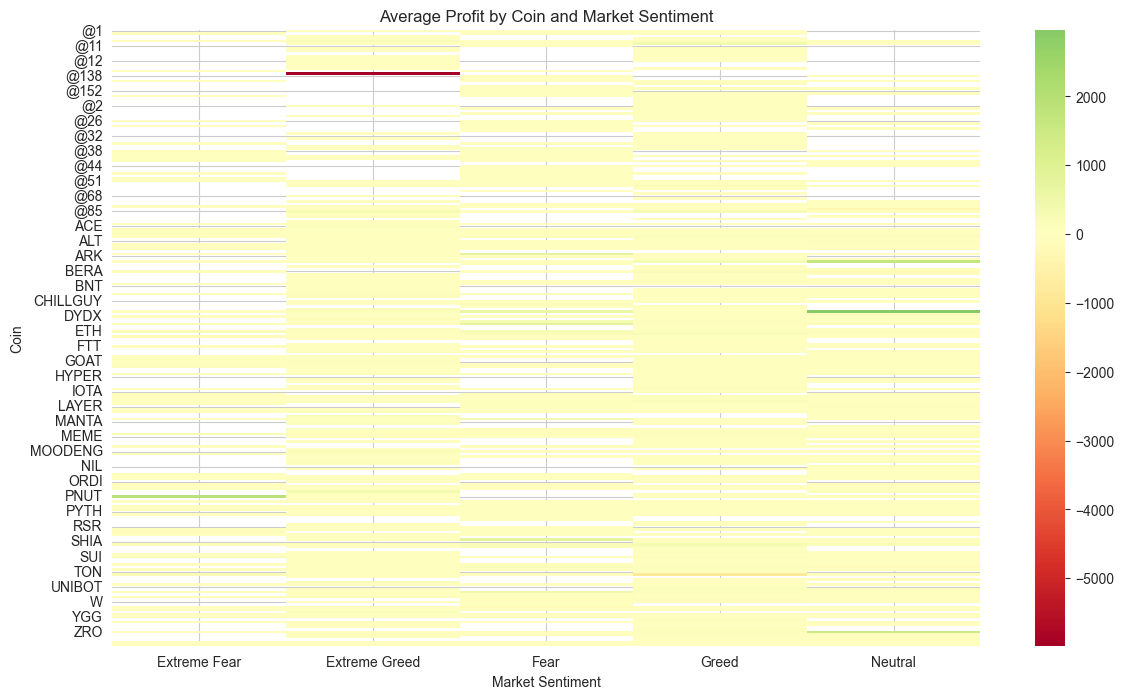

In [102]:
coin_sentiment_profit = (
    merged_df.groupby(
        ["Coin","Market Sentiment"]
    )["Closed PnL"]
    .mean()
    .unstack()
)

plt.figure(figsize=(14,8))

sns.heatmap(
    coin_sentiment_profit,
    cmap="RdYlGn",
    center=0
)

plt.title("Average Profit by Coin and Market Sentiment")

plt.show()

### Trading Activity by Month:

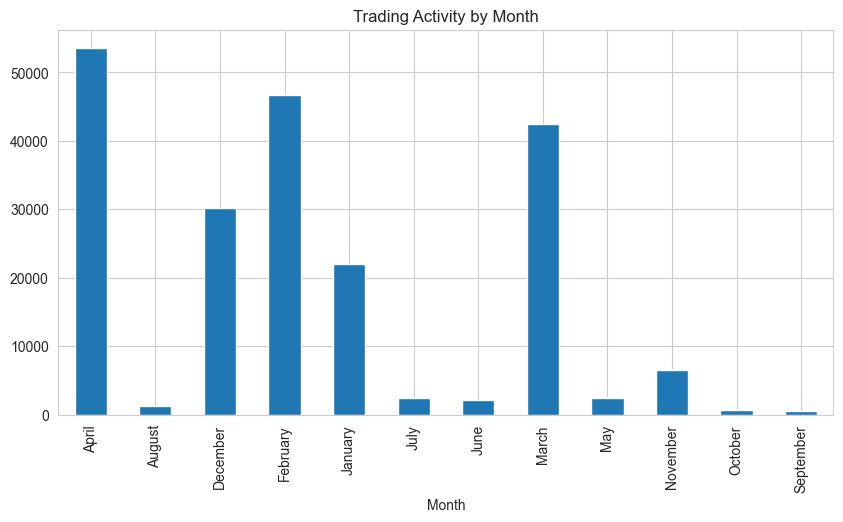

In [103]:
monthly_trade = (
    merged_df.groupby("Month")
    .size()
)

monthly_trade.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Trading Activity by Month")

plt.show()

### Weekend Profitability:

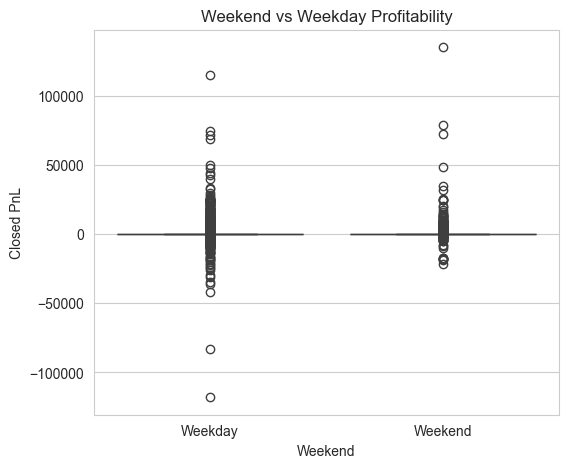

In [104]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=merged_df,
    x="Weekend",
    y="Closed PnL"
)

plt.title("Weekend vs Weekday Profitability")

plt.show()

# Hypothesis Testing & Statistical Validation

## Hypothesis 1

### Business Question

Does Bitcoin market sentiment significantly affect trader profitability?

### Null Hypothesis (H₀)

There is **no significant difference** in the average Closed PnL across different market sentiment categories.

### Alternative Hypothesis (H₁)

There **is a significant difference** in the average Closed PnL across different market sentiment categories.

In [106]:
# Create groups for ANOVA

groups = [
    group["Closed PnL"].values
    for _, group in merged_df.groupby("Market Sentiment")
]

In [107]:
from scipy.stats import f_oneway           #perform ANOVA

f_stat, p_value = f_oneway(*groups)

print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_value:.6f}")

F-Statistic : 9.0622
P-Value     : 0.000000


In [108]:
alpha = 0.05                                       #decision

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


##### Interpretation

If the p-value is less than 0.05, trader profitability differs significantly across market sentiment categories.

Otherwise, any observed differences are likely due to random variation.

## Hypothesis 2

### Business Question

Does market sentiment influence the average trade size?

### Null Hypothesis (H₀)

Average trade size is the same across all market sentiment categories.

### Alternative Hypothesis (H₁)

Average trade size differs significantly across market sentiment categories.

In [109]:
groups = [
    group["Size USD"].values
    for _, group in merged_df.groupby("Market Sentiment")
]

f_stat, p_value = stats.f_oneway(*groups)

print(f"F Statistic : {f_stat:.4f}")
print(f"P Value     : {p_value:.6f}")

F Statistic : 108.2960
P Value     : 0.000000


In [110]:
if p_value < 0.05:                                                 #decision
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


## Hypothesis 3

### Business Question

Is there a significant relationship between trade size and trader profitability?

### Null Hypothesis (H₀)

There is no linear relationship between trade size and Closed PnL.

### Alternative Hypothesis (H₁)

There is a significant linear relationship between trade size and Closed PnL.

In [111]:
corr, p = stats.pearsonr(                           #Pearson Correlation
    merged_df["Size USD"],
    merged_df["Closed PnL"]
)

print("Correlation :", round(corr,4))
print("P Value :", p)

Correlation : 0.1236
P Value : 0.0


In [112]:
if p < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


## Hypothesis 4

### Business Question

Is trading activity uniformly distributed across different market sentiment categories?

### Null Hypothesis (H₀)

Trading activity is independent of market sentiment.

### Alternative Hypothesis (H₁)

Trading activity depends on market sentiment.

In [114]:
from scipy.stats import chi2_contingency                               #Chi-square test

contingency = pd.crosstab(
    merged_df["Market Sentiment"],
    merged_df["Profit Flag"]
)

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi Square :", chi2)
print("P Value :", p)

Chi Square : 821.9982894874004
P Value : 1.3189723316261992e-176


In [115]:
if p < 0.05:                                                        #Decision
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


#### Statistical Validation Summary Table

In [119]:
summary = pd.DataFrame({
    "Hypothesis": [
        "Closed PnL vs Market Sentiment",
        "Trade Size vs Market Sentiment",
        "Trade Size vs Closed PnL",
        "Profit Flag vs Market Sentiment"
    ],
    "Statistical Test": [
        "One-Way ANOVA",
        "One-Way ANOVA",
        "Pearson Correlation",
        "Chi-Square Test"
    ],
    "Test Statistic": [
        9.0622,
        108.2960,
        0.1236,
        821.9983
    ],
    "P-Value": [
        "< 0.001",
        "< 0.001",
        "< 0.001",
        "< 0.001"
    ],
    "Decision": [
        "Reject H₀",
        "Reject H₀",
        "Reject H₀",
        "Reject H₀"
    ]
})

summary

,Hypothesis,Statistical Test,Test Statistic,P-Value,Decision
0,Closed PnL vs Market Sentiment,One-Way ANOVA,9.06,< 0.001,Reject H₀
1,Trade Size vs Market Sentiment,One-Way ANOVA,108.30,< 0.001,Reject H₀
2,Trade Size vs Closed PnL,Pearson Correlation,0.12,< 0.001,Reject H₀
3,Profit Flag vs Market Sentiment,Chi-Square Test,822.00,< 0.001,Reject H₀


#### Statistical Validation Summary

The statistical tests were performed to validate the visual observations obtained during Exploratory Data Analysis.

The results indicate whether the observed relationships between market sentiment, trade size, and trader profitability are statistically significant or simply due to random variation.

These findings provide stronger evidence for the business insights presented in this analysis.

# Hidden Pattern Discovery

The exploratory data analysis and statistical validation revealed several hidden patterns regarding trader behavior, market sentiment, and trading performance.

These findings go beyond simple visual observations and provide meaningful insights that can support better trading strategies and decision-making.

### Hidden Pattern 1: Market Sentiment Significantly Influences Trader Profitability

The ANOVA test confirmed that trader profitability differs significantly across different market sentiment categories (p-value < 0.001).

Although trading activity was highest during **Fear**, the highest average Closed PnL was observed during **Extreme Greed**. This indicates that higher trading activity does not necessarily result in higher profitability.

**Key Insight:** Market conditions influence trading performance, but trader success depends on strategy rather than participation alone.

### Hidden Pattern 2: Trader Participation Peaks During Fear

The sentiment distribution analysis showed that nearly one-third of all trades were executed during **Fear**, making it the most active market condition.

This suggests that traders become highly active during uncertain market conditions, possibly attempting to capitalize on increased price volatility.

**Key Insight:** Fear encourages higher market participation, but increased activity does not guarantee better trading outcomes.

### Hidden Pattern 3: Larger Trade Sizes Do Not Guarantee Higher Profits

The Pearson Correlation analysis revealed a **weak positive correlation (r = 0.1236)** between trade size and Closed PnL.

Although statistically significant, the relationship is weak, indicating that increasing trade size alone has minimal impact on profitability.

**Key Insight:** Trading strategy and market timing contribute more to profitability than simply increasing position size.

### Hidden Pattern 4: Market Sentiment Influences Trade Size

The ANOVA test showed a statistically significant difference in trade sizes across different market sentiment categories (p-value < 0.001).

This suggests that traders adjust their position sizes based on prevailing market sentiment, reflecting changes in confidence and perceived market risk.

**Key Insight:** Trader risk appetite changes with market psychology.

### Hidden Pattern 5: Winning Rate Changes Across Market Sentiments

The winning rate analysis revealed that **Extreme Greed** achieved the highest winning percentage, while **Extreme Fear** recorded the lowest.

This indicates that bullish market conditions generally provide a more favorable environment for successful trades compared to periods of extreme market pessimism.

**Key Insight:** Market sentiment influences not only profitability but also the probability of executing successful trades.

### Hidden Pattern 6: Cryptocurrency Trading Exhibits High Volatility

The Closed PnL histogram and boxplot revealed a highly skewed distribution with numerous extreme profit and loss values.

Rather than representing data errors, these outliers reflect the highly volatile nature of cryptocurrency markets and the presence of high-value trades.

**Key Insight:** Robust statistical measures such as the median and interquartile range are more reliable than simple averages when analyzing cryptocurrency trading data.

### Hidden Pattern 7: Trading Activity Follows a Time-Based Pattern

Trading activity was highest during evening hours and significantly higher on weekdays than weekends.

This suggests that traders tend to participate more actively during periods of higher global market liquidity.

**Key Insight:** The timing of trade execution may influence trading opportunities and market efficiency.

### Hidden Pattern 8: Trader Profitability Depends on Market Sentiment

The Chi-Square Test confirmed that the probability of executing a profitable trade depends significantly on market sentiment (p-value < 0.001).

This finding reinforces that trader success is closely linked to prevailing market conditions rather than occurring randomly.

**Key Insight:** Understanding market sentiment can improve decision-making and increase the likelihood of successful trades.

### Hidden Pattern Summary

The analysis identified several important patterns:

- Market sentiment significantly affects trader profitability.
- Fear attracts the highest trading activity, while Extreme Greed generates the highest average profitability.
- Trade size has only a weak relationship with profitability.
- Traders adjust their position sizes according to market sentiment.
- Winning rates vary across different market conditions.
- Cryptocurrency markets exhibit significant volatility with legitimate extreme profit and loss values.
- Trading behavior follows distinct daily and weekly patterns.
- Market sentiment significantly influences the probability of successful trades.

These findings provide valuable evidence that market psychology plays a critical role in shaping trader behavior and trading performance.

# Business Recommendations

Based on the exploratory data analysis, statistical validation, and hidden pattern discovery, the following recommendations are proposed to improve trading performance and support better decision-making.

### 1. Incorporate Market Sentiment into Trading Decisions

The analysis confirmed that trader profitability varies significantly across different market sentiment categories.

**Recommendation:**
Traders should consider incorporating the Bitcoin Fear & Greed Index into their decision-making process before entering or exiting positions, as market sentiment has a measurable impact on trading performance.

### 2. Focus on Trade Quality Instead of Trade Quantity

Fear accounted for the highest trading activity, but not the highest average profitability.

**Recommendation:**
Rather than increasing the number of trades during volatile market conditions, traders should prioritize high-quality trading opportunities supported by technical and risk analysis.

### 3. Avoid Increasing Position Size Solely Based on Market Confidence

Although trade size differed across sentiment categories, the correlation between trade size and profitability was weak.

**Recommendation:**
Position sizing should be determined using proper risk management principles instead of emotional market sentiment or overconfidence.

### 4. Strengthen Risk Management During Extreme Fear

The analysis showed lower winning rates during Extreme Fear.

**Recommendation:**
During periods of extreme market pessimism, traders should adopt stricter stop-loss strategies, reduce leverage, and limit unnecessary exposure to minimize potential losses.

### 5. Capitalize on Favorable Market Conditions

Extreme Greed recorded both the highest average profitability and the highest winning percentage.

**Recommendation:**
Rather than blindly following bullish sentiment, traders should identify high-probability setups during strong market momentum while maintaining disciplined risk management.

### 6. Monitor Trading Performance Using Multiple Metrics

The Closed PnL distribution contained numerous extreme values, making average profit alone an unreliable performance indicator.

**Recommendation:**
Trading performance should be evaluated using multiple metrics such as average profit, median profit, winning rate, and risk-adjusted returns instead of relying solely on cumulative profit.

### 7. Optimize Trading Time

Trading activity was significantly higher during specific hours of the day and on weekdays.

**Recommendation:**
Scheduling trading activities during periods of higher market participation may improve liquidity, execution efficiency, and trading opportunities.

### 8. Develop Sentiment-Aware Trading Strategies

The statistical analysis confirmed that market sentiment significantly influences trader behavior and profitability.

**Recommendation:**
Future algorithmic or AI-based trading systems should integrate sentiment indicators with technical and quantitative signals to improve prediction accuracy and decision-making.

### Recommendation Summary

The analysis suggests that successful cryptocurrency trading depends not only on market direction but also on understanding trader psychology, market sentiment, disciplined risk management, and effective position sizing.

Integrating sentiment analysis with data-driven trading strategies can help traders make more informed decisions and improve long-term trading performance.

# 14. Conclusion

This project analyzed the relationship between Bitcoin market sentiment and trader performance by combining the Bitcoin Fear & Greed Index with historical trading data.

The exploratory data analysis revealed meaningful differences in trader behavior, profitability, trade size, and trading activity across different market sentiment categories. Statistical hypothesis testing further confirmed that these relationships are statistically significant rather than occurring due to random chance.

Key findings include:

- Market sentiment significantly influences trader profitability.
- Fear generated the highest trading activity, whereas Extreme Greed produced the highest average profitability and winning rate.
- Trade size has only a weak positive relationship with profitability, indicating that larger positions alone do not guarantee better trading outcomes.
- Trading behavior varies across different market conditions, highlighting the importance of disciplined risk management and sentiment-aware decision-making.

Overall, the analysis demonstrates that Bitcoin market sentiment is an important factor influencing trader behavior and performance. Integrating sentiment indicators with quantitative trading strategies can support more informed decision-making and improve trading effectiveness.